In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [2]:
images = []
fits_files = ["M13_0001.fits","M13_0002.fits","M13_0003.fits","M13_0004.fits","M13_0005.fits"]

for file in fits_files:
    with fits.open(f"../../course_assignments/homework10/{file}") as hdul:
        data = hdul[0].data
        images.append(data)

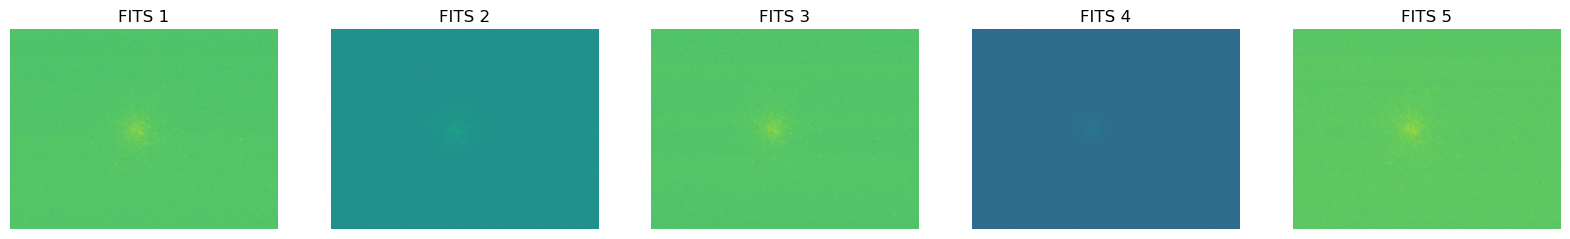

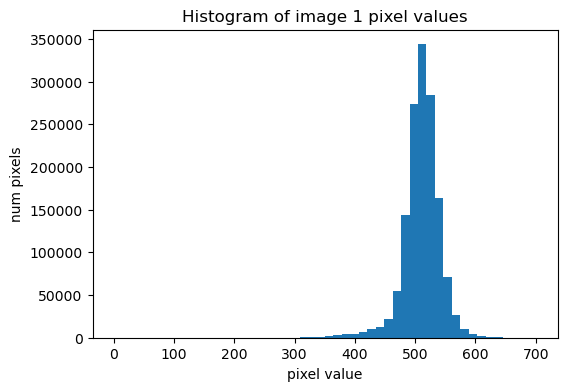

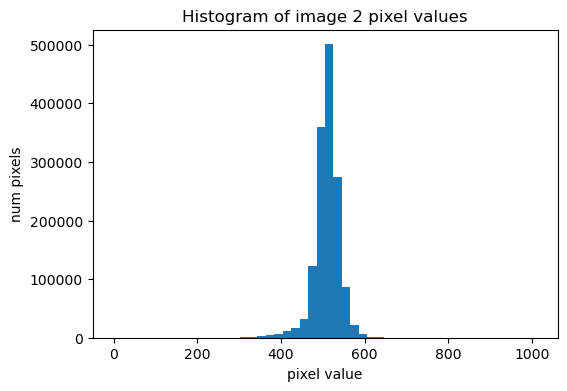

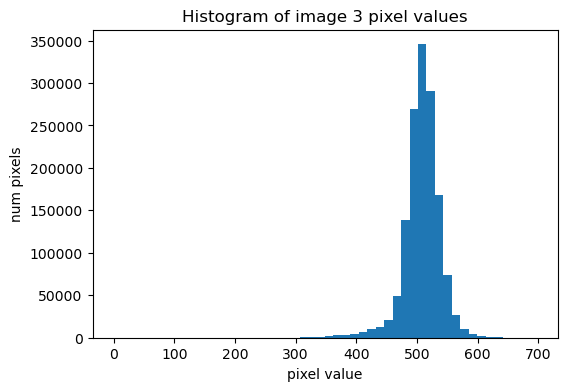

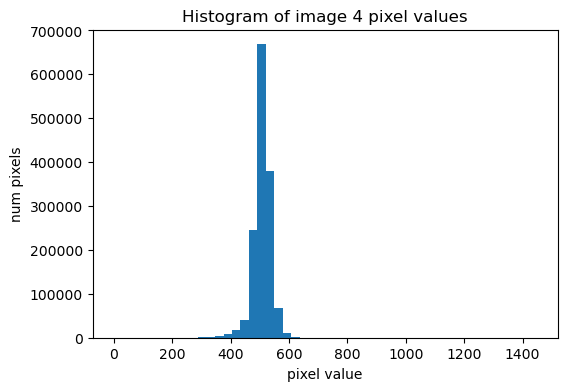

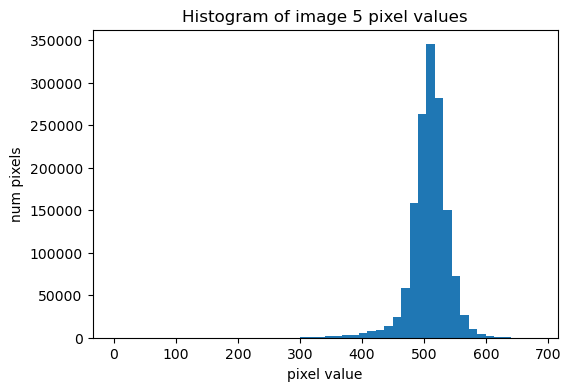

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, image in enumerate(images):
    im = axes[i].imshow(image, origin="lower")
    axes[i].set_title(f"FITS {i+1}")
    axes[i].axis('off')
    
for i, image in enumerate(images):
    plt.figure(figsize=(6,4))
    plt.hist(image.ravel(),bins=50)
    plt.title(f"Histogram of image {i+1} pixel values")
    plt.xlabel("pixel value")
    plt.ylabel("num pixels")
    plt.show()

plt.show()

#x axis shows the value, y shows the number of pixels 
#bins = 50 means we separate by 50 bins in the histogram
#it's centered at around 500, it's not very spread out only by like 200
#median is around 500 too

In [4]:
combined_image = np.median(np.array(images), axis=0)
median_intensity = np.median(combined_image)

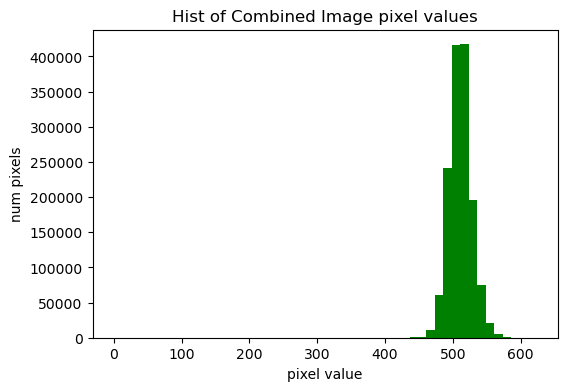

In [5]:
plt.figure(figsize=(6,4))
plt.hist(combined_image.ravel(), bins=50, color='green')
plt.title("Hist of Combined Image pixel values")
plt.xlabel("pixel value")
plt.ylabel("num pixels")
plt.show()

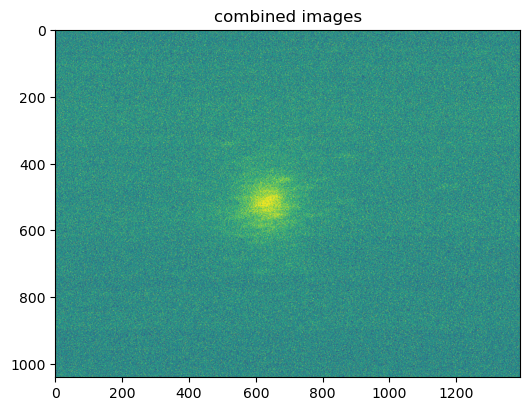

In [6]:
vmin = median_intensity-50
vmax = median_intensity+50

plt.figure(figsize=(6,6))
plt.imshow(combined_image, vmin=vmin, vmax=vmax)
plt.title("combined images")
plt.show()

fits.writeto("combined.fits", combined_image, overwrite=True)